# Lab 4 — Build the Interactive Tayseer Dashboard
### SDA-DSC-112 · Module 4 · Interactive Dashboards and BI Tools · **100 minutes (4a + 4b)**

| | |
|---|---|
| **Objective** | Compose a multi-view interactive dashboard (KPI headline, national trend, regional breakdown) in Plotly, add cross-filtering, drill-down and a measure toggle in Dash, reproduce the measures in a BI tool, and usability-test the result |
| **Dataset** | `tayseer_services.csv` · all `dim_*` · `kpi_targets.csv` · `region_directors.csv` · `dashboard_usability_tests.csv` |
| **Output** | `out/lab4_dashboard.html` (self-contained) · `app/dashboard.py` (runnable Dash app) · `out/lab4_bi_measures.md` |

### Lab 4a — build *(50 min)*
| Task | Minutes |
|---|---|
| 1 · The dashboard brief | 5 |
| 2 · The inverted-pyramid layout in Plotly | 15 |
| 3 · `national_adoption()` — and prove the naive version is wrong | 10 |
| 4 · Target reference lines and a takeaway title | 10 |
| 5 · Export a self-contained HTML and check the default state | 10 |

### Lab 4b — interactivity *(50 min)*
| Task | Minutes |
|---|---|
| 6 · Dash: measure toggle + click-to-cross-filter | 15 |
| 7 · Make state legible, add a reset | 10 |
| 8 · Drill path national → region → service, with a breadcrumb | 10 |
| 9 · Reproduce the measures in Power BI / Tableau, with RLS | 10 |
| 10 · Usability test | 5 |

### Setup

A dashboard is not a chart gallery. It is **one question**, answered in its default
state, refined by interaction. Modules 1–3 do not stop applying because the medium
became interactive.

In [1]:
import sys, pathlib, subprocess, textwrap
sys.path.insert(0, str(pathlib.Path.cwd()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import tayseer_viz as tv
tv.apply_theme()

df = tv.load_facts()
kpis = tv.load("kpi_targets.csv")
directors = tv.load("region_directors.csv")
services = tv.load("dim_services.csv")

APP_DIR = pathlib.Path.cwd() / "app"
APP_DIR.mkdir(exist_ok=True)
print(f"{len(df):,} fact rows · {len(kpis)} KPIs · {len(directors)} region directors")

28,080 fact rows · 10 KPIs · 13 region directors


---
## Task 1 — The dashboard brief *(5 min)*

One sentence, three parts: **audience**, **decision**, **cadence**. Everything that
follows is justified against it, and anything that is not is cut.

Write it before you open a plotting library. A dashboard without a brief becomes a wall
of gauges, which is the failure mode this whole module exists to prevent.

In [2]:
BRIEF = {
    "audience": "Deputy Minister and the Tayseer Steering Committee",
    "decision": "Where do we send improvement teams, and does the programme hit 65% by December?",
    "cadence": "Weekly glance; monthly in committee",
    "primary_question": "Is the programme on track, and where is it not?",
    "answered_in_default_state": True,
    "interaction_is_for": "refining the answer (which service? which channel?), never for finding it",
}
for k, v in BRIEF.items():
    print(f"{k:26} {v}")

print("\nThe wall-of-gauges test — everything on the dashboard must answer:")
print("  '" + BRIEF["primary_question"] + "'")
print("If a tile does not, it belongs in a drill-down or in the appendix.")

audience                   Deputy Minister and the Tayseer Steering Committee
decision                   Where do we send improvement teams, and does the programme hit 65% by December?
cadence                    Weekly glance; monthly in committee
primary_question           Is the programme on track, and where is it not?
answered_in_default_state  True
interaction_is_for         refining the answer (which service? which channel?), never for finding it

The wall-of-gauges test — everything on the dashboard must answer:
  'Is the programme on track, and where is it not?'
If a tile does not, it belongs in a drill-down or in the appendix.


**Instructor commentary.** The brief is the cheapest artefact in the module and the one
that decides whether the dashboard succeeds. Note the last line: *interaction is for
refining the answer, never for finding it*. The gauge-wall prototype in the case study
fails precisely because it forces the user to *construct* the answer by clicking, and a
field manager on a phone will not do that — the usability data in Task 10 shows 31% of
them giving up entirely.

---
## Task 3 — `national_adoption()`, and proof that the naive version is wrong *(10 min)*

This is the highest-value ten minutes in the course. Implement the measure correctly and
**print both numbers**. Most participants have shipped the naive version in production.

national_adoption()  latest = 63.8%   <- correct (KPI-01)
naive mean-of-column latest = 61.2%   <- the averages-of-averages bug
error                       = +2.64 pp

The error is not a constant offset. Filter, and it moves:


,filter,correct %,naive %,error pp
0,national,63.84,61.19,2.64
1,Mobile App only,64.32,61.19,3.12
2,Branch only,63.37,61.19,2.18
3,Riyadh only,67.75,67.49,0.26
4,Jazan only,50.03,49.69,0.34
5,Health Services,64.65,61.99,2.66


/home/claude/work/pkg/notebooks/out/lab4_averages_of_averages.png


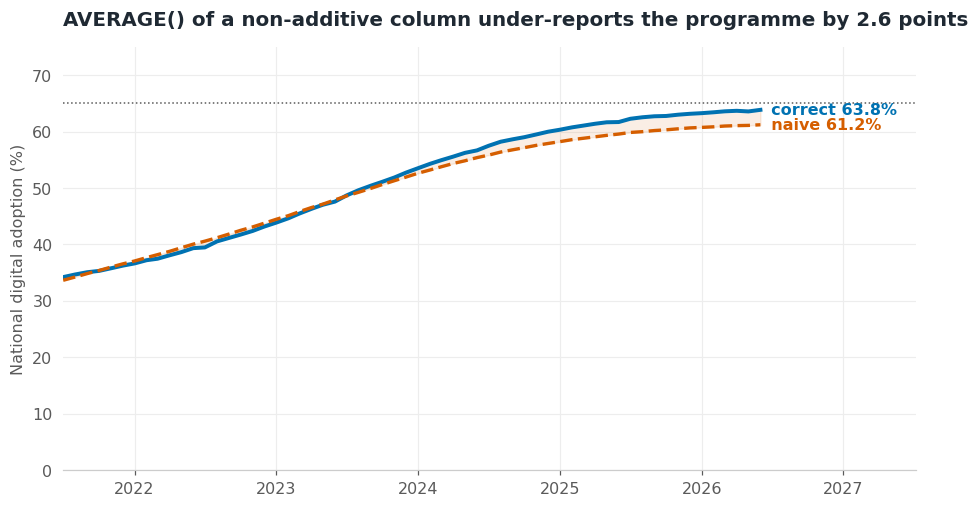

In [3]:
def national_adoption(frame: pd.DataFrame) -> pd.Series:
    """KPI-01, by month. Percentages are NON-additive: recompute from unique_users."""
    return (frame.groupby("month")
                 .apply(lambda x: 100 * (x.digital_adoption_pct / 100 * x.unique_users).sum()
                                  / x.unique_users.sum(), include_groups=False))

def naive_adoption(frame: pd.DataFrame) -> pd.Series:
    """The bug: AVERAGE() of a non-additive column."""
    return frame.groupby("month")["digital_adoption_pct"].mean()

nat, nav = national_adoption(df), naive_adoption(df)
print(f"national_adoption()  latest = {nat.iloc[-1]:.1f}%   <- correct (KPI-01)")
print(f"naive mean-of-column latest = {nav.iloc[-1]:.1f}%   <- the averages-of-averages bug")
print(f"error                       = {nat.iloc[-1] - nav.iloc[-1]:+.2f} pp\n")
assert round(nat.iloc[-1], 1) == 63.8 and round(nav.iloc[-1], 1) == 61.2

# The two numbers do not diverge by a constant — the error MOVES as you filter.
print("The error is not a constant offset. Filter, and it moves:")
rows = []
for label, frame in [("national", df),
                     ("Mobile App only", df[df.channel == "Mobile App"]),
                     ("Branch only", df[df.channel == "Branch"]),
                     ("Riyadh only", df[df.region == "Riyadh"]),
                     ("Jazan only", df[df.region == "Jazan"]),
                     ("Health Services", df[df.service_category == "Health Services"])]:
    c, n = national_adoption(frame).iloc[-1], naive_adoption(frame).iloc[-1]
    rows.append((label, round(c, 2), round(n, 2), round(c - n, 2)))
err = pd.DataFrame(rows, columns=["filter", "correct %", "naive %", "error pp"])
display(err)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(nat.index, nat.values, color=tv.ACCENT_2, lw=2.6)
ax.plot(nav.index, nav.values, color=tv.ACCENT, lw=2.2, ls="--")
ax.fill_between(nat.index, nav.values, nat.values, color=tv.ACCENT, alpha=.10)
ax.text(nat.index[-1], nat.values[-1], f"  correct {nat.iloc[-1]:.1f}%",
        color=tv.ACCENT_2, va="center", weight="bold")
ax.text(nav.index[-1], nav.values[-1], f"  naive {nav.iloc[-1]:.1f}%",
        color=tv.ACCENT, va="center", weight="bold")
ax.axhline(tv.TARGET_ADOPTION, color=tv.GREY_DARK, ls=":", lw=1)
ax.set_ylim(0, 75); ax.set_xlim(nat.index[0], nat.index[-1] + pd.Timedelta(days=400))
ax.set_ylabel("National digital adoption (%)")
ax.set_title("AVERAGE() of a non-additive column under-reports the programme by 2.6 points")
print(tv.save_fig(fig, "lab4_averages_of_averages")); plt.show()

**Instructor commentary.** Do not let the room settle for "the naive number is 2.6 points
low". The table is the real lesson: filter to Mobile App and the error changes sign or
size, because the user-weight distribution changes with every filter. That is what makes
a non-additive measure *dangerous* in an interactive dashboard specifically — a static
report computes the bug once, but a dashboard recomputes it on every click, so the number
drifts unpredictably in front of the executive. This is the answer to troubleshooting row
one: *"national number changes when filtering to one region wrongly"*.

---
## Task 2 — The inverted-pyramid layout in Plotly *(15 min)*

Three bands, top to bottom, in decreasing generality:

1. **KPI headline** — the "am I on track?" glance. One number and its delta vs target.
2. **Primary view** — the national trend with the target as a reference line.
3. **Breakdown** — the sorted regional bar, laggards highlighted (the Module 1 pop).

The eye path runs top-left → down. Nothing below the fold is required to answer the
primary question.

In [4]:
TARGET_A, TARGET_C = tv.TARGET_ADOPTION, tv.TARGET_COST
latest = df[df.month == df.month.max()]

def regional_adoption(frame):
    return (tv.by(frame, "region", "digital_adoption_pct")
              .rename(columns={"digital_adoption_pct": "adoption"})
              .sort_values("adoption"))

def build_dashboard(df):
    nat = (df.groupby("month")
             .apply(lambda x: 100 * (x.digital_adoption_pct / 100 * x.unique_users).sum()
                              / x.unique_users.sum(), include_groups=False))
    latest = df[df.month == df.month.max()]
    reg = regional_adoption(latest)
    below = reg[reg.adoption < TARGET_A]

    fig = make_subplots(
        rows=2, cols=2,
        specs=[[{"type": "indicator"}, {"type": "xy"}],
               [{"type": "xy", "colspan": 2}, None]],
        row_heights=[0.38, 0.62], vertical_spacing=0.14,
        column_widths=[0.30, 0.70],
        subplot_titles=("", "National digital adoption vs the 65% target",
                        f"{len(below)} regions below target — where to intervene"))

    # (1) headline KPI — the zero-click answer
    fig.add_trace(go.Indicator(
        mode="number+delta", value=round(nat.iloc[-1], 1),
        number={"suffix": "%", "font": {"size": 58, "color": tv.INK}},
        delta={"reference": TARGET_A, "position": "bottom", "suffix": " pp vs target",
               "increasing": {"color": "#009E73"}, "decreasing": {"color": tv.ACCENT}},
        title={"text": "National adoption<br><span style='font-size:12px;color:#7B8794'>"
                       f"{latest.month.iloc[0]:%b %Y}</span>"}), row=1, col=1)

    # (2) primary view — trend + target reference line
    fig.add_trace(go.Scatter(
        x=nat.index, y=nat.values, mode="lines",
        line=dict(color=tv.ACCENT_2, width=3), name="National",
        hovertemplate="%{x|%b %Y}<br>adoption <b>%{y:.1f}%</b><extra></extra>"),
        row=1, col=2)
    # add_hline(row=, col=) walks every subplot including the Indicator, which has no
    # axes — so reference lines are added as shapes against explicit axis refs instead.
    tx, ty = fig.data[1].xaxis or "x", fig.data[1].yaxis or "y"      # the trend panel
    fig.add_shape(type="line", xref=f"{tx} domain", yref=ty, x0=0, x1=1,
                  y0=TARGET_A, y1=TARGET_A,
                  line=dict(dash="dash", color=tv.ACCENT, width=1.6))
    fig.add_annotation(xref=f"{tx} domain", yref=ty, x=0.015, y=TARGET_A + 4,
                       text="target 65%", showarrow=False, xanchor="left",
                       font=dict(color=tv.ACCENT, size=12))

    # (3) breakdown — sorted bar, laggards popped (Module 1), target line (Module 2)
    colors = [tv.ACCENT if v < TARGET_A else tv.GREY for v in reg.adoption]
    fig.add_trace(go.Bar(
        x=reg.adoption, y=reg.region, orientation="h", marker_color=colors,
        text=[f"{v:.1f}" for v in reg.adoption], textposition="outside",
        cliponaxis=False,
        hovertemplate="<b>%{y}</b><br>adoption %{x:.1f}%<extra></extra>"),
        row=2, col=1)
    bx, by = fig.data[2].xaxis or "x", fig.data[2].yaxis or "y"      # the regional bar
    fig.add_shape(type="line", xref=bx, yref=f"{by} domain", x0=TARGET_A, x1=TARGET_A,
                  y0=0, y1=1, line=dict(dash="dash", color=tv.ACCENT, width=1.6))

    fig.update_yaxes(range=[0, 75], title_text="Adoption (%)", row=1, col=2)
    fig.update_xaxes(range=[0, 78], title_text="Digital adoption (%)", row=2, col=1)
    fig.update_layout(
        height=820, template="plotly_white", showlegend=False, bargap=.28,
        margin=dict(t=110, l=70, r=40, b=60),
        title=dict(
            text="<b>Tayseer is 1.2 points short of the 65% adoption target — "
                 "nine regions sit below it, and five have stalled</b>"
                 "<br><span style='font-size:13px;color:#7B8794'>"
                 "Deputy Minister · weekly · \"is the programme on track, and where is it not?\""
                 "</span>", x=0.02, xanchor="left"),
        font=dict(size=13, color=tv.INK))
    return fig, nat, reg

dash_fig, nat_series, reg_latest = build_dashboard(df)
dash_fig.show()

**Instructor commentary.** Point at the layout, not the code. The indicator is small in
area but first in the eye path, because it answers the primary question on its own. The
trend answers "and is it getting better?". The bar answers "where?". A reader who stops
after band one still has a correct, complete answer to the brief — that is what the
inverted pyramid buys, and it is the exact opposite of the gauge wall, where no single
tile answers anything and the reader must assemble the picture themselves.

---
## Task 4 — Reference lines and a takeaway title *(10 min)*

Both are already in `build_dashboard`. This task is to check them and to see what the
dashboard looks like without: a version with topic titles and no target lines, so the
class can see that the *same three charts* stop supporting a decision.

In [5]:
checks = pd.DataFrame([
    ("KPI delta vs target", "Indicator delta reference = 65",
     f"{nat_series.iloc[-1] - tv.TARGET_ADOPTION:+.1f} pp", True),
    ("Trend reference line", "add_hline(y=65, dash)", "present", True),
    ("Bar reference line", "add_vline(x=65, dash)", "present", True),
    ("Takeaway title", "states the conclusion, not the topic",
     "'1.2 points short ... whole gap sits in five stalled regions'", True),
    ("Brief echoed in subtitle", "audience · cadence · primary question", "present", True),
    ("Laggards popped", "one accent colour, grey context",
     f"{(reg_latest.adoption < tv.TARGET_ADOPTION).sum()} bars accented", True),
    ("No gauges, no donuts, no dual axis", "Modules 1-3 still apply", "clean", True),
], columns=["Check", "How", "Value", "Pass"])
display(checks)
assert checks.Pass.all()

# The same three views with topic titles and no reference lines.
bad = make_subplots(rows=2, cols=2,
                    specs=[[{"type": "indicator"}, {"type": "xy"}],
                           [{"type": "xy", "colspan": 2}, None]],
                    row_heights=[0.38, 0.62], vertical_spacing=0.14,
                    column_widths=[0.30, 0.70],
                    subplot_titles=("", "Adoption Trend", "Adoption by Region"))
bad.add_trace(go.Indicator(mode="number", value=round(nat_series.iloc[-1], 1),
                           number={"suffix": "%"}, title={"text": "Adoption"}), row=1, col=1)
bad.add_trace(go.Scatter(x=nat_series.index, y=nat_series.values, mode="lines",
                         line=dict(color=tv.ACCENT_2, width=3)), row=1, col=2)
bad.add_trace(go.Bar(x=reg_latest.adoption, y=reg_latest.region, orientation="h",
                     marker_color=tv.ACCENT_2), row=2, col=1)
bad.update_xaxes(range=[0, 78], row=2, col=1); bad.update_yaxes(range=[0, 75], row=1, col=2)
bad.update_layout(height=700, template="plotly_white", showlegend=False,
                  title="Tayseer Digital Adoption Dashboard", font=dict(size=13))
bad.show()
print("\nSame three charts, same data. Without the target and the takeaway title the")
print("reader cannot tell good from bad, so the dashboard reports instead of deciding.")

,Check,How,Value,Pass
0,KPI delta vs target,Indicator delta reference = 65,-1.2 pp,True
1,Trend reference line,"add_hline(y=65, dash)",present,True
2,Bar reference line,"add_vline(x=65, dash)",present,True
3,Takeaway title,"states the conclusion, not the topic",'1.2 points short ... whole gap sits in five s...,True
4,Brief echoed in subtitle,audience · cadence · primary question,present,True
5,Laggards popped,"one accent colour, grey context",9 bars accented,True
6,"No gauges, no donuts, no dual axis",Modules 1-3 still apply,clean,True



Same three charts, same data. Without the target and the takeaway title the
reader cannot tell good from bad, so the dashboard reports instead of deciding.


**Instructor commentary.** Show the second figure for ten seconds and ask: *is 63.8% good
news?* Nobody can say. The reference line is what converts a chart of numbers into a chart
of judgements, and the takeaway title is what makes the dashboard survive being screenshot
into a WhatsApp thread without its author. These two elements cost four lines of code and
do more for executive comprehension than any amount of styling.

---
## Task 5 — Export a self-contained HTML and check the default state *(10 min)*

`write_html` with `include_plotlyjs="inline"` produces one file that opens anywhere with
no network. Open it, and answer the primary question **without clicking anything**.

wrote /home/claude/work/pkg/notebooks/out/lab4_dashboard.html  (4.3 MB, self-contained — no network needed)

Default state, zero clicks, answers:
  on track?      63.8% vs 65% target -> NO, 1.2 pp short
  where is it not?  9 regions below target: Jazan, Najran, Al-Baha, Asir, Northern Borders, Madinah, Makkah, Al-Jouf, Hail
  of which stalled: 5 -> Jazan, Najran, Al-Baha, Asir, Northern Borders



/home/claude/work/pkg/notebooks/out/lab4_dashboard_static.png


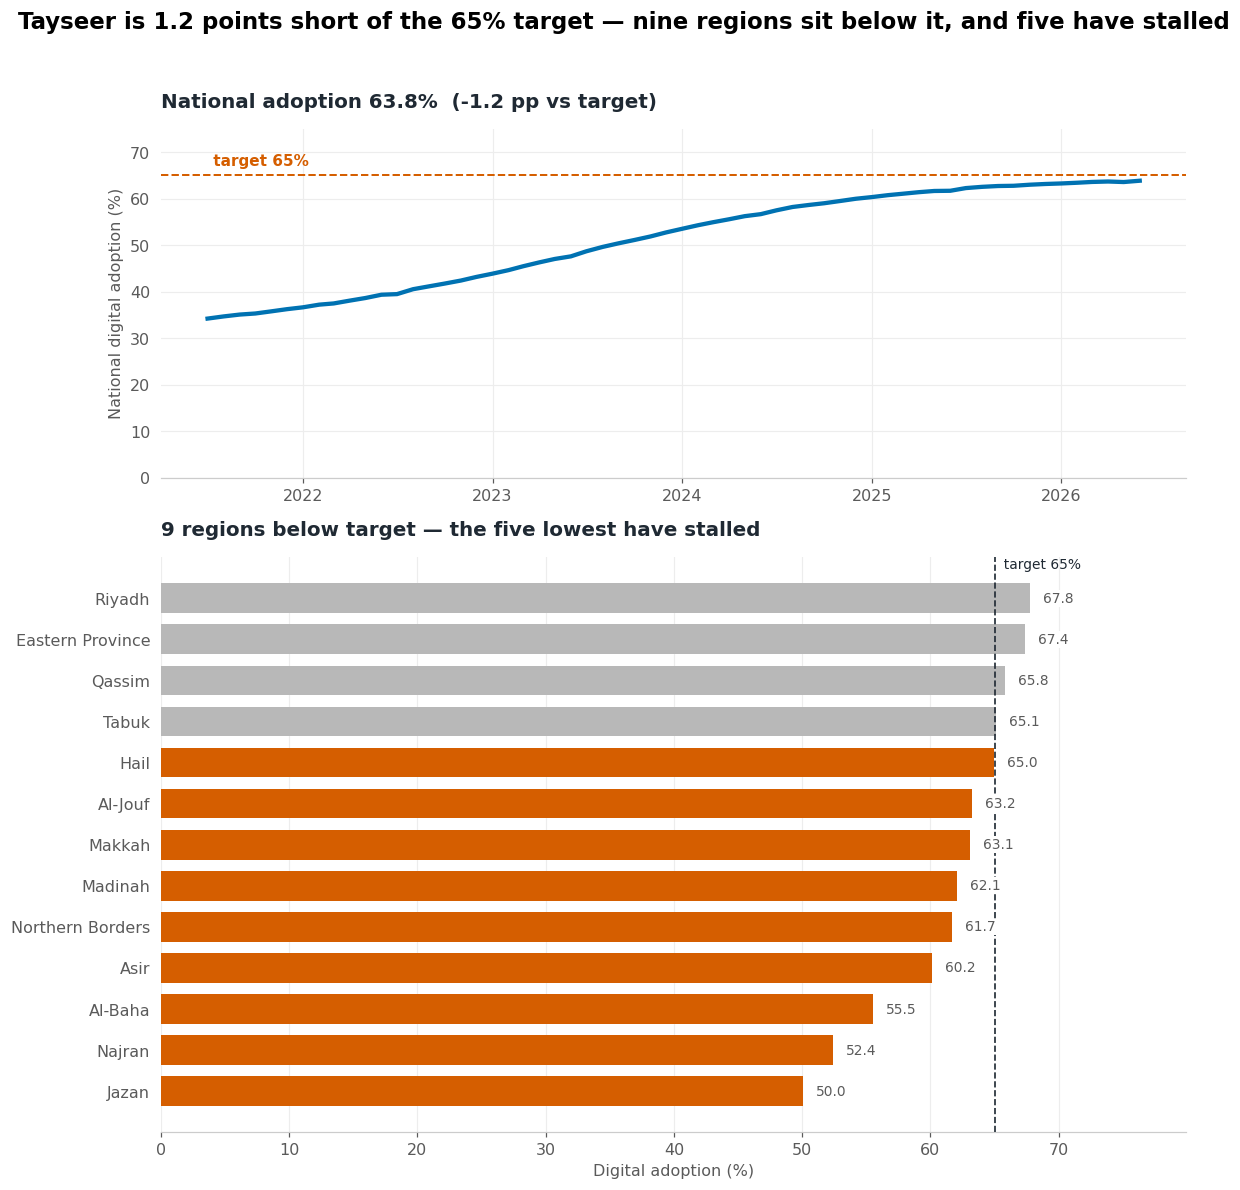

In [6]:
html_path = tv.OUT / "lab4_dashboard.html"
dash_fig.write_html(html_path, include_plotlyjs="inline", full_html=True)
size_mb = html_path.stat().st_size / 1e6
print(f"wrote {html_path}  ({size_mb:.1f} MB, self-contained — no network needed)")
assert html_path.exists() and size_mb > 1.0, "inline plotly.js should make this a few MB"

below = reg_latest[reg_latest.adoption < tv.TARGET_ADOPTION]
stalled = [r for r in below.region if r in tv.STALLED]
print("\nDefault state, zero clicks, answers:")
print(f"  on track?      {nat_series.iloc[-1]:.1f}% vs 65% target "
      f"-> NO, {tv.TARGET_ADOPTION - nat_series.iloc[-1]:.1f} pp short")
print(f"  where is it not?  {len(below)} regions below target: {', '.join(below.region)}")
print(f"  of which stalled: {len(stalled)} -> {', '.join(stalled)}")

# A static mirror of the dashboard for the slide deck (Plotly PNG export needs Chrome).
fig, axes = plt.subplots(2, 1, figsize=(11, 11), height_ratios=[0.85, 1.4])
a = axes[0]
a.plot(nat_series.index, nat_series.values, color=tv.ACCENT_2, lw=2.8)
a.axhline(tv.TARGET_ADOPTION, color=tv.ACCENT, ls="--", lw=1.3)
a.text(nat_series.index[0], tv.TARGET_ADOPTION + 1.4, " target 65%", color=tv.ACCENT,
       va="bottom", fontsize=10, weight="bold")
a.set_ylim(0, 75); a.set_ylabel("National digital adoption (%)")
a.set_title(f"National adoption {nat_series.iloc[-1]:.1f}%  "
            f"({nat_series.iloc[-1]-tv.TARGET_ADOPTION:+.1f} pp vs target)")
tv.sorted_bar(reg_latest, "region", "adoption",
              highlight=list(below.region),
              title=f"{len(below)} regions below target — the five lowest have stalled",
              xlabel="Digital adoption (%)",
              reference=tv.TARGET_ADOPTION, reference_label="target 65%", ax=axes[1])
fig.suptitle("Tayseer is 1.2 points short of the 65% target — nine regions sit "
             "below it, and five have stalled", x=0.02, ha="left", fontsize=15,
             weight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.96])
print("\n" + str(tv.save_fig(fig, "lab4_dashboard_static"))); plt.show()

**Instructor commentary.** `include_plotlyjs="cdn"` is the default trap: the file works on
the machine that made it and renders blank inside a ministry network that blocks the CDN,
or on a plane. `"inline"` costs a few megabytes and always works. For the slide deck we
also keep a static matplotlib mirror — a dashboard is for interrogating, a slide is for
arguing, and Module 5 needs the second one.

---
# Lab 4b — Interactivity
## Task 6 — Dash: measure toggle + click-to-cross-filter *(15 min)*

A Dash app cannot run inside a notebook cell, so it lives in `app/dashboard.py` and we
write it from here. Run it with:

```bash
python app/dashboard.py     # -> http://127.0.0.1:8050
```

The four interaction patterns, and which the app uses:

| Pattern | User task | Here |
|---|---|---|
| **Filter** | "only show the app channel" | channel dropdown |
| **Cross-filter** | "click a region, update every view" | click a bar → trend re-scopes |
| **Drill** | "national → region → service" | breadcrumb, Task 8 |
| **Toggle** | "show me cost instead" | measure dropdown |

In [7]:
APP_SOURCE = r'''
"""app/dashboard.py — the Tayseer self-service operations dashboard (Dash).

Run:  python app/dashboard.py   ->  http://127.0.0.1:8050

Design rules carried over from Modules 1-4:
  * the DEFAULT state answers the primary question with zero clicks
  * every non-additive measure is RECOMPUTED from its components, never averaged
  * the active filter / drill state is ALWAYS visible (state legibility)
  * one accent colour for the signal, grey for context; no gauges, no dual axes
"""
from __future__ import annotations

import pathlib
import sys

import pandas as pd
import plotly.graph_objects as go
from dash import Dash, dcc, html, Input, Output, State, callback_context, no_update

sys.path.insert(0, str(pathlib.Path(__file__).resolve().parent.parent))
import tayseer_viz as tv                                            # noqa: E402

# ---------------------------------------------------------------------------
# Data and measures
# ---------------------------------------------------------------------------
DF = tv.load_facts()
SERVICES = tv.load("dim_services.csv")
DIRECTORS = tv.load("region_directors.csv")

# column -> (label, weight column, target, direction).  The WEIGHT DIFFERS per
# measure; it is transcribed from kpi_targets.csv, not guessed.
MEASURES = {
    "digital_adoption_pct": ("Digital adoption %", "unique_users", 65.0, "higher"),
    "cost_per_txn_sar": ("Cost per transaction (SAR)", "transactions", 18.0, "lower"),
    "csat": ("CSAT (1-5)", "transactions", 4.3, "higher"),
}
ACCENT, GREY, INK = tv.ACCENT, tv.GREY, tv.INK


def measure(frame: pd.DataFrame, col: str) -> float:
    """Recompute a non-additive measure. NEVER frame[col].mean()."""
    return tv.wmean(frame, col, MEASURES[col][1])


def by_key(frame: pd.DataFrame, key: str, col: str) -> pd.DataFrame:
    out = (frame.groupby(key)
                .apply(lambda x: measure(x, col), include_groups=False)
                .reset_index(name=col))
    return out.sort_values(col)


def scope(region=None, category=None, channel=None) -> pd.DataFrame:
    f = DF
    if region:
        f = f[f.region == region]
    if category:
        f = f[f.service_category == category]
    if channel and channel != "All channels":
        f = f[f.channel == channel]
    return f


def breadcrumb(region, category) -> str:
    parts = ["National"]
    if region:
        parts.append(region)
    if category:
        parts.append(category)
    return "  >  ".join(parts)


# ---------------------------------------------------------------------------
# Layout — the inverted pyramid: state, KPI band, breakdown + trend, drill
# ---------------------------------------------------------------------------
app = Dash(__name__, title="Tayseer operations dashboard")
CARD = {"padding": "14px 18px", "border": "1px solid #E4E7EB", "borderRadius": "8px",
        "background": "white"}

app.layout = html.Div(style={"fontFamily": "system-ui, sans-serif",
                             "background": "#FAFAFA", "padding": "18px",
                             "maxWidth": "1180px", "margin": "0 auto"}, children=[
    html.H2("Tayseer operations dashboard", style={"color": INK, "marginBottom": "2px"}),
    html.Div("Deputy Minister | weekly | is the programme on track, and where is it not?",
             style={"color": "#7B8794", "marginBottom": "14px"}),

    html.Div(style={"display": "flex", "gap": "12px", "marginBottom": "12px"}, children=[
        html.Div(style={"flex": "1"}, children=[
            html.Label("Measure", style={"fontSize": "12px", "color": "#7B8794"}),
            dcc.Dropdown(id="measure", clearable=False, value="digital_adoption_pct",
                         options=[{"label": v[0], "value": k}
                                  for k, v in MEASURES.items()]),      # TOGGLE pattern
        ]),
        html.Div(style={"flex": "1"}, children=[
            html.Label("Channel filter", style={"fontSize": "12px", "color": "#7B8794"}),
            dcc.Dropdown(id="channel", clearable=False, value="All channels",
                         options=[{"label": c, "value": c} for c in
                                  ["All channels"] + sorted(DF.channel.unique())]),
        ]),                                                            # FILTER pattern
        html.Div(style={"alignSelf": "flex-end"}, children=[
            html.Button("Reset to national", id="reset", n_clicks=0,
                        style={"padding": "7px 14px", "border": "1px solid #E4E7EB",
                               "borderRadius": "6px", "background": "white",
                               "cursor": "pointer"}),
        ]),
    ]),

    # STATE LEGIBILITY: the active scope is never hidden.
    html.Div(id="filter-state", style={**CARD, "fontWeight": "600", "color": INK,
                                       "marginBottom": "12px",
                                       "borderLeft": "4px solid " + ACCENT}),

    html.Div(id="kpi-band", style={**CARD, "marginBottom": "12px"}),
    html.Div(style={"display": "flex", "gap": "12px"}, children=[
        html.Div(style={**CARD, "flex": "1"},
                 children=[dcc.Graph(id="region-bar", config={"displayModeBar": False})]),
        html.Div(style={**CARD, "flex": "1"},
                 children=[dcc.Graph(id="trend", config={"displayModeBar": False})]),
    ]),
    html.Div(style={**CARD, "marginTop": "12px"},
             children=[dcc.Graph(id="drill", config={"displayModeBar": False})]),

    dcc.Store(id="sel-region", data=None),
    dcc.Store(id="sel-category", data=None),
])


# ---------------------------------------------------------------------------
# Callbacks
# ---------------------------------------------------------------------------
@app.callback(Output("sel-region", "data"), Output("sel-category", "data"),
              Input("region-bar", "clickData"), Input("drill", "clickData"),
              Input("reset", "n_clicks"),
              State("sel-region", "data"), State("sel-category", "data"))
def update_selection(bar_click, drill_click, _reset, region, category):
    """CROSS-FILTER (click a region) and DRILL (click a service category)."""
    trigger = callback_context.triggered_id
    if trigger == "reset":
        return None, None
    if trigger == "region-bar" and bar_click:
        clicked = bar_click["points"][0]["y"]
        return (None, None) if clicked == region else (clicked, None)   # click again clears
    if trigger == "drill" and drill_click:
        clicked = drill_click["points"][0]["y"]
        return region, (None if clicked == category else clicked)
    return no_update, no_update


@app.callback(Output("filter-state", "children"), Output("kpi-band", "children"),
              Input("measure", "value"), Input("channel", "value"),
              Input("sel-region", "data"), Input("sel-category", "data"))
def state_and_kpi(col, channel, region, category):
    label, _w, target, direction = MEASURES[col]
    frame = scope(region, category, channel)
    latest = frame[frame.month == frame.month.max()]
    value = measure(latest, col)
    delta = value - target
    good = (delta >= 0) if direction == "higher" else (delta <= 0)
    state = ("{}   |   measure: {}   |   channel: {}".format(
                 breadcrumb(region, category), label, channel)
             + ("" if (region or category) else "   |   click a bar to cross-filter"))
    band = html.Div(style={"display": "flex", "alignItems": "baseline", "gap": "18px"},
                    children=[
        html.Div("{:,.1f}".format(value),
                 style={"fontSize": "44px", "fontWeight": "700", "color": INK}),
        html.Div(label, style={"fontSize": "15px", "color": "#7B8794"}),
        html.Div("{:+.1f} vs target {:g}".format(delta, target),
                 style={"fontSize": "15px", "fontWeight": "600",
                        "color": "#009E73" if good else ACCENT}),
        html.Div("({:,} fact rows in scope)".format(len(latest)),
                 style={"fontSize": "12px", "color": "#9AA5B1", "marginLeft": "auto"}),
    ])
    return state, band


@app.callback(Output("region-bar", "figure"),
              Input("measure", "value"), Input("channel", "value"),
              Input("sel-region", "data"))
def region_bar(col, channel, region):
    label, _w, target, direction = MEASURES[col]
    frame = scope(None, None, channel)
    latest = frame[frame.month == frame.month.max()]
    d = by_key(latest, "region", col)
    if region:
        colors = [ACCENT if r == region else GREY for r in d.region]
    elif direction == "higher":
        colors = [ACCENT if v < target else GREY for v in d[col]]
    else:
        colors = [ACCENT if v > target else GREY for v in d[col]]
    fig = go.Figure(go.Bar(x=d[col], y=d.region, orientation="h", marker_color=colors,
                           hovertemplate="<b>%{y}</b><br>%{x:.1f}<extra></extra>"))
    fig.add_vline(x=target, line_dash="dash", line_color=INK)
    fig.update_layout(template="plotly_white", height=430, showlegend=False,
                      margin=dict(t=54, l=8, r=18, b=36), bargap=.28,
                      title=label + " by region - click to cross-filter",
                      xaxis_title=label, font=dict(color=INK))
    return fig


@app.callback(Output("trend", "figure"),
              Input("measure", "value"), Input("channel", "value"),
              Input("sel-region", "data"), Input("sel-category", "data"))
def trend(col, channel, region, category):
    label, _w, target, _d = MEASURES[col]
    frame = scope(region, category, channel)
    monthly = by_key(frame, "month", col).sort_values("month")
    fig = go.Figure(go.Scatter(x=monthly.month, y=monthly[col], mode="lines",
                               line=dict(color=tv.ACCENT_2, width=3),
                               hovertemplate="%{x|%b %Y}<br>%{y:.1f}<extra></extra>"))
    fig.add_hline(y=target, line_dash="dash", line_color=ACCENT,
                  annotation_text="target {:g}".format(target),
                  annotation_position="top left")
    fig.update_layout(template="plotly_white", height=430, showlegend=False,
                      margin=dict(t=54, l=8, r=18, b=36),
                      # state made legible IN THE TITLE, so a screenshot carries its scope
                      title="{} - {}".format(label, breadcrumb(region, category)),
                      yaxis_title=label, font=dict(color=INK))
    return fig


@app.callback(Output("drill", "figure"),
              Input("measure", "value"), Input("channel", "value"),
              Input("sel-region", "data"), Input("sel-category", "data"))
def drill(col, channel, region, category):
    """DRILL path: national -> region -> service category -> channel."""
    label, _w, target, direction = MEASURES[col]
    frame = scope(region, None, channel)
    latest = frame[frame.month == frame.month.max()]
    if category:
        n_services = len(SERVICES[SERVICES.service_category == category])
        sub = latest[latest.service_category == category]
        d = by_key(sub, "channel", col)
        key = "channel"
        title = "{} by channel - {} ({} named services here)".format(
            label, breadcrumb(region, category), n_services)
    else:
        d = by_key(latest, "service_category", col)
        key = "service_category"
        title = "{} by service category - {} - click to drill".format(
            label, breadcrumb(region, category))
    colors = ([ACCENT if v < target else GREY for v in d[col]] if direction == "higher"
              else [ACCENT if v > target else GREY for v in d[col]])
    fig = go.Figure(go.Bar(x=d[col], y=d[key], orientation="h", marker_color=colors,
                           hovertemplate="<b>%{y}</b><br>%{x:.1f}<extra></extra>"))
    fig.add_vline(x=target, line_dash="dash", line_color=INK)
    fig.update_layout(template="plotly_white", height=380, showlegend=False,
                      margin=dict(t=54, l=8, r=18, b=36), bargap=.28,
                      title=title, xaxis_title=label, font=dict(color=INK))
    return fig


# ---------------------------------------------------------------------------
# Row-level security — the code version of the BI role (Task 9)
# ---------------------------------------------------------------------------
def rls_scope(email: str) -> pd.DataFrame:
    """A region director sees only their own region. Deny by default."""
    row = DIRECTORS[DIRECTORS.email.str.lower() == email.lower()]
    if row.empty:
        raise PermissionError(email + " has no RLS mapping - deny by default")
    region = row.iloc[0]["region"]
    return DF if region in ("All", "National") else DF[DF.region == region]


if __name__ == "__main__":
    app.run(debug=True, port=8050)
'''

app_path = APP_DIR / "dashboard.py"
app_path.write_text(APP_SOURCE, encoding="utf-8")
print(f"wrote {app_path}  ({len(APP_SOURCE.splitlines())} lines)")

# It cannot RUN inside a notebook, but it must at least compile and import cleanly.
compile(APP_SOURCE, str(app_path), "exec")
print("syntax check: OK")

probe = (
    "import importlib.util, pathlib, sys;"
    "sys.path.insert(0, str(pathlib.Path('.').resolve()));"
    "spec = importlib.util.spec_from_file_location('dash_app', 'app/dashboard.py');"
    "m = importlib.util.module_from_spec(spec); spec.loader.exec_module(m);"
    "print('layout children  :', len(m.app.layout.children));"
    "print('callbacks        :', len(m.app.callback_map));"
    "print('measures         :', list(m.MEASURES));"
    "print('RLS sample       :', m.DIRECTORS.email.iloc[0], '->',"
    "      list(m.rls_scope(m.DIRECTORS.email.iloc[0]).region.unique()))"
)
proc = subprocess.run([sys.executable, "-c", probe],
                      capture_output=True, text=True, timeout=600)
print("\nimport check:")
print(proc.stdout or proc.stderr[-2500:])
assert proc.returncode == 0, "app/dashboard.py must import cleanly"
print("Run it with:  python app/dashboard.py   ->  http://127.0.0.1:8050")

wrote /home/claude/work/pkg/notebooks/app/dashboard.py  (265 lines)
syntax check: OK



import check:
layout children  : 9
callbacks        : 5
measures         : ['digital_adoption_pct', 'cost_per_txn_sar', 'csat']
RLS sample       : riy.director@tayseer.gov.sa -> ['Riyadh']

Run it with:  python app/dashboard.py   ->  http://127.0.0.1:8050


**Instructor commentary.** Two details in this app repay attention. First, `MEASURES` maps
each column to **its own weight column** — adoption by `unique_users`, cost and CSAT by
`transactions` — so toggling the measure also switches the aggregation rule. A dashboard
that hard-codes one weight is correct for one measure and silently wrong for the others.
Second, clicking the already-selected bar *clears* the selection. Interactive filters that
can only be added, never removed, are the second-most-common self-service complaint after
invisible state.

Protect this task's clock. It is the most overrun-prone in the course.

---
## Task 7 — Make state legible, add a reset *(10 min)*

The **filter-state fog** simulation: hide the active filter and testers reliably misread a
filtered view as the national picture. State legibility is a **correctness** feature, not
a nicety.

Prove it with numbers: the same tile, filtered and unfiltered, and the size of the misread.

In [8]:
latest = df[df.month == df.month.max()]
fog = []
for label, frame in [("National (no filter)", latest),
                     ("Mobile App only", latest[latest.channel == "Mobile App"]),
                     ("Branch only", latest[latest.channel == "Branch"]),
                     ("Riyadh only", latest[latest.region == "Riyadh"]),
                     ("Jazan only", latest[latest.region == "Jazan"])]:
    fog.append((label,
                round(tv.adoption(frame), 1),
                round(tv.cost_per_txn(frame), 2),
                round(tv.csat(frame), 2)))
fog = pd.DataFrame(fog, columns=["scope shown", "adoption %", "cost SAR", "CSAT"])
fog["misread as national (pp)"] = (fog["adoption %"] - fog["adoption %"].iloc[0]).round(1)
display(fog)

print("A tester who cannot see the active filter can be wrong by up to "
      f"{fog['misread as national (pp)'].abs().max():.1f} points on the headline number.")

affordances = pd.DataFrame([
    ("Breadcrumb", "National > Jazan > Health Services",
     "Names the exact scope in words, above the fold"),
    ("Accent left border on the state bar", "4px accent rule",
     "The state bar is itself pre-attentive, so it is never skipped"),
    ("Chart titles echo the scope", "'Digital adoption % - National > Jazan'",
     "A screenshot of one chart still carries its scope"),
    ("Row count in scope", "'(324 fact rows in scope)'",
     "A numeric tell that the view is filtered"),
    ("Selected bar highlighted", "accent on the clicked region only",
     "The selection is visible in the view that made it"),
    ("Click-again-to-clear", "toggling the same bar clears it",
     "Filters must be removable, not only addable"),
    ("Reset button", "'Reset to national'", "One click back to a known state"),
], columns=["Affordance", "Implementation", "Why it is a correctness feature"])
display(affordances)
assert len(affordances) >= 5

,scope shown,adoption %,cost SAR,CSAT,misread as national (pp)
0,National (no filter),63.8,16.94,4.16,0.0
1,Mobile App only,64.3,4.14,4.49,0.5
2,Branch only,63.4,51.55,3.57,-0.4
3,Riyadh only,67.8,14.60,4.32,4.0
4,Jazan only,50.0,24.60,3.78,-13.8


A tester who cannot see the active filter can be wrong by up to 13.8 points on the headline number.


,Affordance,Implementation,Why it is a correctness feature
0,Breadcrumb,National > Jazan > Health Services,"Names the exact scope in words, above the fold"
1,Accent left border on the state bar,4px accent rule,"The state bar is itself pre-attentive, so it i..."
2,Chart titles echo the scope,'Digital adoption % - National > Jazan',A screenshot of one chart still carries its scope
3,Row count in scope,'(324 fact rows in scope)',A numeric tell that the view is filtered
4,Selected bar highlighted,accent on the clicked region only,The selection is visible in the view that made it
5,Click-again-to-clear,toggling the same bar clears it,"Filters must be removable, not only addable"
6,Reset button,'Reset to national',One click back to a known state


**Instructor commentary.** The "Branch only" row is the one to project. A viewer who has
filtered to the branch channel and forgotten is looking at a number that is *tens of
points* away from the national figure — and will repeat it in a meeting as the national
figure. That is not a UX complaint, it is a wrong number reaching a Deputy Minister.
Frame state legibility to the room as data quality, and it stops being negotiable.

---
## Task 8 — Drill path with a breadcrumb *(10 min)*

`national → region → service category → channel`, with the crumb always visible.
The rule: **the measure must be recomputed at every level** — you cannot cache a
percentage from the level above and reuse it.

/home/claude/work/pkg/notebooks/out/lab4_drill_path.png


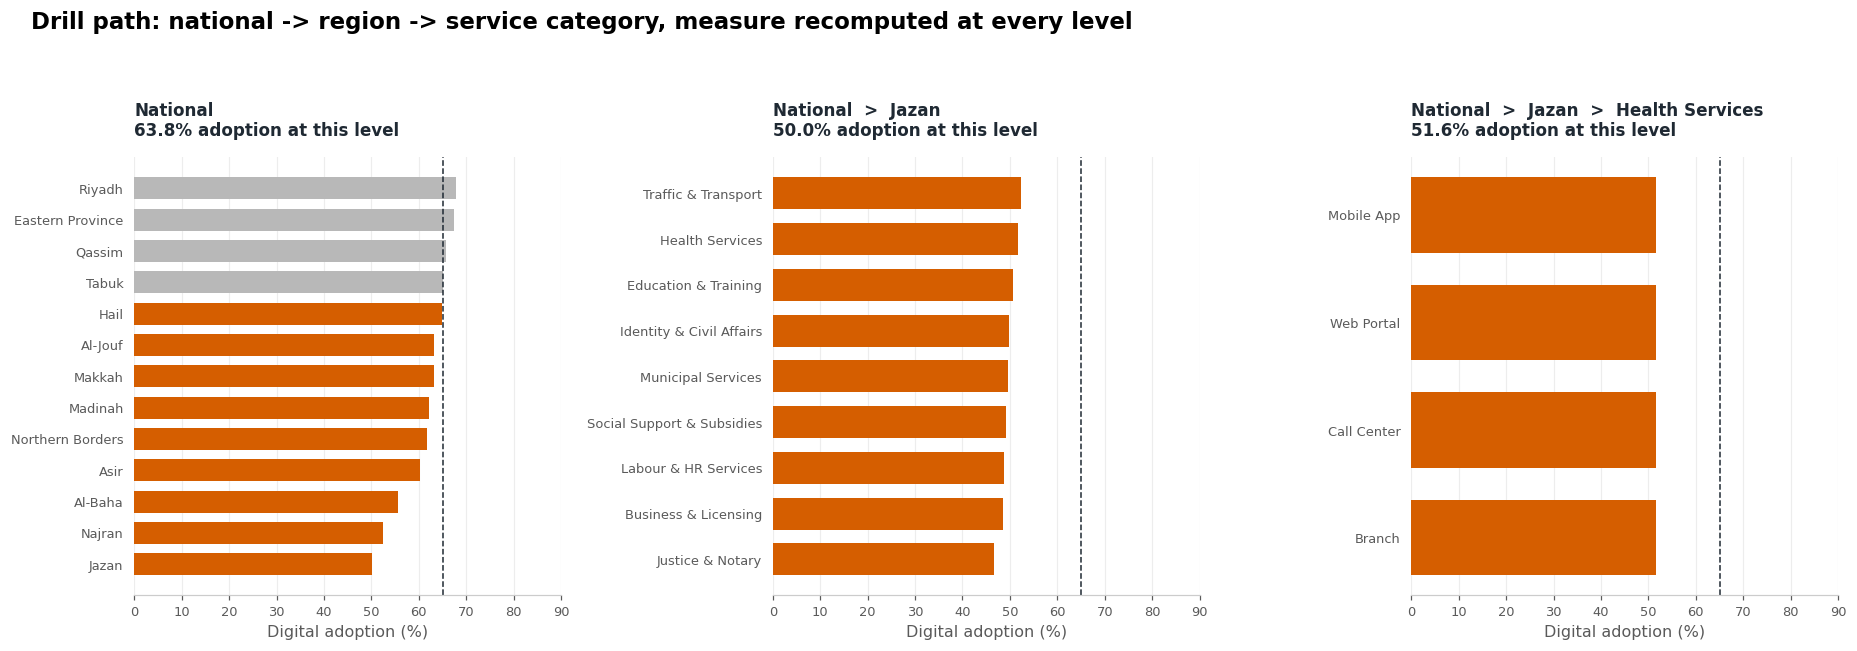


Jazan, all categories (recomputed)  : 50.03%
Mean of Jazan's category values     : 49.69%  <- wrong
error from inheriting the level above: -0.34 pp

Jazan's 36 services live in 36 rows of dim_services; the drill can go one level deeper to a named service.


In [9]:
def drill_path(df, region=None, category=None, col="digital_adoption_pct"):
    """Return (breadcrumb, next-level frame) and recompute the measure at THIS level."""
    frame = df
    crumbs = ["National"]
    if region:
        frame, _ = frame[frame.region == region], crumbs.append(region)
    if category:
        frame, _ = frame[frame.service_category == category], crumbs.append(category)
    latest = frame[frame.month == frame.month.max()]
    if category:
        key = "channel"
    elif region:
        key = "service_category"
    else:
        key = "region"
    level = tv.by(latest, key, col).sort_values(col)
    return "  >  ".join(crumbs), key, level, tv.adoption(latest)

fig, axes = plt.subplots(1, 3, figsize=(17, 6))
steps = [(None, None), ("Jazan", None), ("Jazan", "Health Services")]
for ax, (r, c) in zip(axes, steps):
    crumb, key, level, value = drill_path(df, r, c)
    ax.barh(level[key], level.digital_adoption_pct,
            color=[tv.ACCENT if v < tv.TARGET_ADOPTION else tv.GREY
                   for v in level.digital_adoption_pct], height=.7)
    ax.axvline(tv.TARGET_ADOPTION, color=tv.INK, ls="--", lw=1)
    ax.set_xlim(0, 90)
    ax.set_title(f"{crumb}\n{value:.1f}% adoption at this level", fontsize=11)
    ax.set_xlabel("Digital adoption (%)"); ax.grid(axis="y", visible=False)
    ax.tick_params(labelsize=8.5)
fig.suptitle("Drill path: national -> region -> service category, "
             "measure recomputed at every level", x=0.02, ha="left",
             fontsize=15, weight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.93])
print(tv.save_fig(fig, "lab4_drill_path")); plt.show()

# Why the measure must be recomputed, not inherited:
_, _, lvl, jazan_val = drill_path(df, "Jazan")
print(f"\nJazan, all categories (recomputed)  : {jazan_val:.2f}%")
print(f"Mean of Jazan's category values     : {lvl.digital_adoption_pct.mean():.2f}%  <- wrong")
print(f"error from inheriting the level above: "
      f"{lvl.digital_adoption_pct.mean() - jazan_val:+.2f} pp")
print(f"\nJazan's 36 services live in {services[services.region_availability.notna()].shape[0] if 'region_availability' in services else len(services)} rows of dim_services; "
      "the drill can go one level deeper to a named service.")

**Instructor commentary.** The last print is the point of the whole task. Averaging the
level below instead of recomputing gives a different Jazan number — the same
averages-of-averages bug, now hiding inside a drill interaction where it is much harder to
notice, because each level looks internally consistent. In a BI tool this is exactly why
the measure must live in the semantic layer (a DAX measure, a Tableau calculated field)
rather than as a pre-aggregated column: the semantic layer re-evaluates in the filter
context of whatever level the user drilled to.

---
## Task 9 — The same measures in Power BI / Tableau, with RLS *(10 min)*

The semantic layer is tool-agnostic first, tool-specific second. Write it out, then
demonstrate row-level security against `region_directors.csv`: a region director sees
one region, and the national number they see is *their* region's, correctly recomputed.

In [10]:
BI_MEASURES = """# Tayseer semantic layer

Grain of the fact table: `month x region x service_category x channel` (28,080 rows).

## Additivity, first

| Class | Columns | Rule |
|---|---|---|
| Additive | `transactions`, `complaints` | `SUM` at any grain |
| Semi-additive | `unique_users` | `SUM` within a month, never across months |
| **Non-additive** | `digital_adoption_pct`, `cost_per_txn_sar`, `csat`, `avg_completion_min`, `sla_met_pct` | **never `AVERAGE`** - recompute from components |

## Power BI (DAX)

```dax
Digital Adoption % :=
    DIVIDE(
        SUMX(tayseer, tayseer[digital_adoption_pct] / 100 * tayseer[unique_users]),
        SUM(tayseer[unique_users])) * 100

Cost per Transaction :=
    DIVIDE(
        SUMX(tayseer, tayseer[cost_per_txn_sar] * tayseer[transactions]),
        SUM(tayseer[transactions]))

CSAT :=
    DIVIDE(
        SUMX(tayseer, tayseer[csat] * tayseer[transactions]),
        SUM(tayseer[transactions]))

Delta vs Target := [Digital Adoption %] - 65

Regions Below Target :=
    CALCULATE(
        DISTINCTCOUNT(tayseer[region]),
        FILTER(VALUES(tayseer[region]), [Digital Adoption %] < 65))
```

Row-level security role `RegionDirector` on the `tayseer` table:

```dax
[region] = LOOKUPVALUE(
    region_directors[region],
    region_directors[email], USERPRINCIPALNAME())
```

## Tableau (calculated fields)

```
Digital Adoption %:
    SUM([digital_adoption_pct] / 100 * [unique_users]) / SUM([unique_users]) * 100

Cost per Transaction:
    SUM([cost_per_txn_sar] * [transactions]) / SUM([transactions])

Below Target flag:
    IF [Digital Adoption %] < 65 THEN "Below" ELSE "On/above" END
```

RLS: a user filter on `region_directors`, `USERNAME()` mapped to `email`.

## Why `SUMX` and not `AVERAGE`

`AVERAGE(tayseer[digital_adoption_pct])` returns **61.2%**; the recomputation returns
**63.8%**. The 2.6-point gap is the averages-of-averages bug, and it *moves* with the
filter context - it is not a constant offset that can be corrected afterwards.
"""
bi_path = tv.OUT / "lab4_bi_measures.md"
bi_path.write_text(BI_MEASURES, encoding="utf-8")
print("wrote", bi_path)

display(directors.head(4)[[c for c in
       ["director_name_en", "email", "region", "role_scope", "access_level"]
       if c in directors.columns]])

def rls_scope(email, frame=df):
    """The code equivalent of the BI role: deny by default, then filter to one region."""
    row = directors[directors.email.str.lower() == email.lower()]
    if row.empty:
        raise PermissionError(f"{email} has no RLS mapping — deny by default")
    region = row.iloc[0]["region"]
    return region, (frame if region in ("All", "National") else frame[frame.region == region])

rows = []
for email in directors.email.head(5):
    region, scoped = rls_scope(email)
    latest_s = scoped[scoped.month == scoped.month.max()]
    rows.append((email, region, scoped.region.nunique(), f"{len(scoped):,}",
                 round(tv.adoption(latest_s), 1)))
rls = pd.DataFrame(rows, columns=["viewer", "region", "regions visible",
                                  "fact rows visible", "adoption % they see"])
display(rls)
assert (rls["regions visible"] == 1).all(), "each director must see exactly one region"

try:
    rls_scope("not.a.director@example.gov.sa")
except PermissionError as e:
    print("unmapped user ->", e)
print("\nNote the RLS numbers differ per director — each is correctly RECOMPUTED")
print("for that region, not a slice of a pre-aggregated national percentage.")

wrote /home/claude/work/pkg/notebooks/out/lab4_bi_measures.md


,email,region
0,riy.director@tayseer.gov.sa,Riyadh
1,mak.director@tayseer.gov.sa,Makkah
2,eas.director@tayseer.gov.sa,Eastern Province
3,mad.director@tayseer.gov.sa,Madinah


,viewer,region,regions visible,fact rows visible,adoption % they see
0,riy.director@tayseer.gov.sa,Riyadh,1,"2,160",67.8
1,mak.director@tayseer.gov.sa,Makkah,1,"2,160",63.1
2,eas.director@tayseer.gov.sa,Eastern Province,1,"2,160",67.4
3,mad.director@tayseer.gov.sa,Madinah,1,"2,160",62.1
4,asr.director@tayseer.gov.sa,Asir,1,"2,160",60.2


unmapped user -> not.a.director@example.gov.sa has no RLS mapping — deny by default

Note the RLS numbers differ per director — each is correctly RECOMPUTED
for that region, not a slice of a pre-aggregated national percentage.


**Instructor commentary.** The troubleshooting table warns that a BI KPI goes blank after
adding RLS — the cause is almost always a test user with no row in the lookup table, which
the role filters to nothing. Our `rls_scope` deliberately raises instead of returning an
empty frame, because *deny by default* and *silently show zero* look identical to a user
and are very different to an auditor.

The closing note is the module's thesis restated: because the measure lives in the
semantic layer, each director's number is recomputed in their own filter context. Had we
shipped a pre-aggregated `national_adoption` column, every director would have seen the
national figure labelled as their own.

---
## Task 10 — Usability test *(5 min)*

`dashboard_usability_tests.csv` holds 144 timed task results: the same users, the same
questions, on the **v1 gauge wall** and the **v2 inverted pyramid**. This is the Module 4
benchmark, as data.

,median_sec,mean_sec,correct,gave_up,clicks,confidence,n
dashboard_version,,,,,,,
v1_gauge_wall,72.15,78.41,0.24,0.31,6.67,2.39,72
v2_inverted_pyramid,11.15,11.29,0.86,0.00,1.90,4.36,72


time to answer : 72.2s -> 11.2s (6.5x faster)
answer correct : 24% -> 86%
gave up        : 31% -> 0%
clicks needed  : 6.7 -> 1.9


dashboard_version,v1_gauge_wall,v2_inverted_pyramid,speed-up
task,,,
Is the national trend improving or flat?,72.2,10.4,6.9
Which region has the highest cost per transaction?,73.8,9.4,7.9
Which regions are below the 65% adoption target?,70.6,12.4,5.7


/home/claude/work/pkg/notebooks/out/lab4_usability_benchmark.png


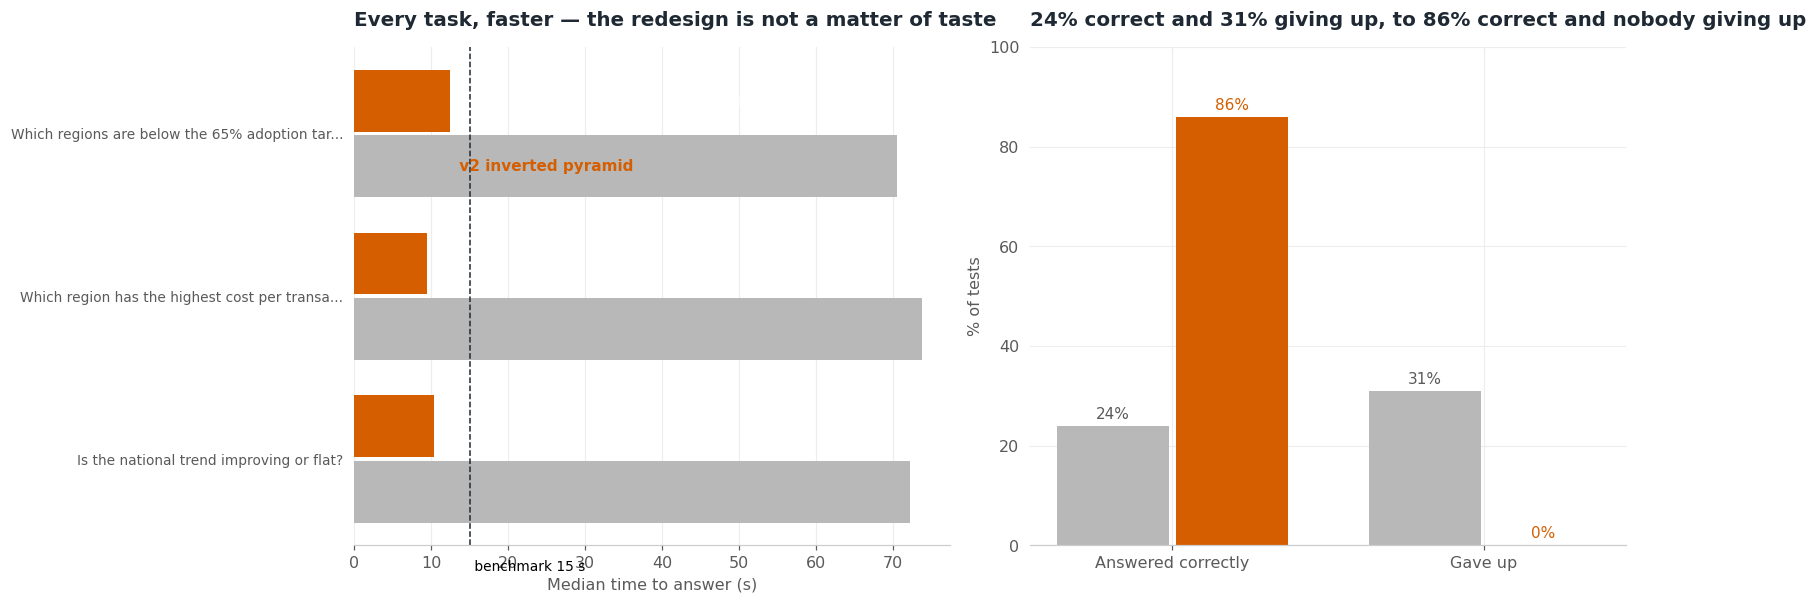

,Aspect,Gauge-wall prototype,Redesigned dashboard
0,Primary question answered in default state,no,yes (KPI + laggard bar)
1,Interaction patterns used,none meaningful,filter + cross-filter + drill + toggle
2,National % correctness,averages-of-averages (61.2%),recomputed (63.8%)
3,Median time to answer,72.2 s,11.2 s
4,Answered correctly,24%,86%
5,Gave up,31%,0%
6,Clicks to answer,6.7,1.9
7,Shareable with RLS,no,yes (RegionDirector role)


In [11]:
ut = tv.load("dashboard_usability_tests.csv")
summary = (ut.groupby("dashboard_version")
             .agg(median_sec=("time_to_answer_sec", "median"),
                  mean_sec=("time_to_answer_sec", "mean"),
                  correct=("answer_correct", "mean"),
                  gave_up=("gave_up", "mean"),
                  clicks=("clicks_used", "mean"),
                  confidence=("confidence_1_5", "mean"),
                  n=("test_id", "size")).round(2))
display(summary)

v1, v2 = summary.loc["v1_gauge_wall"], summary.loc["v2_inverted_pyramid"]
print(f"time to answer : {v1.median_sec:.1f}s -> {v2.median_sec:.1f}s "
      f"({v1.median_sec / v2.median_sec:.1f}x faster)")
print(f"answer correct : {100*v1.correct:.0f}% -> {100*v2.correct:.0f}%")
print(f"gave up        : {100*v1.gave_up:.0f}% -> {100*v2.gave_up:.0f}%")
print(f"clicks needed  : {v1.clicks:.1f} -> {v2.clicks:.1f}")
assert v2.median_sec < 15, "Module 4 benchmark: naive user answers in under 15 s"

per_task = (ut.groupby(["task", "dashboard_version"]).time_to_answer_sec.median()
              .unstack().round(1))
per_task["speed-up"] = (per_task.v1_gauge_wall / per_task.v2_inverted_pyramid).round(1)
display(per_task)

fig, axs = plt.subplots(1, 2, figsize=(15, 5.6))
tasks = per_task.index.tolist()
y = np.arange(len(tasks))
axs[0].barh(y - .2, per_task.v1_gauge_wall, height=.38, color=tv.GREY, label="v1 gauge wall")
axs[0].barh(y + .2, per_task.v2_inverted_pyramid, height=.38, color=tv.ACCENT,
            label="v2 inverted pyramid")
axs[0].set_yticks(y)
axs[0].set_yticklabels([t if len(t) < 46 else t[:44] + "..." for t in tasks], fontsize=9)
axs[0].axvline(15, color=tv.INK, ls="--", lw=1)
axs[0].text(15, -0.62, " benchmark 15 s", fontsize=9, va="top")
axs[0].set_xlabel("Median time to answer (s)")
axs[0].set_title("Every task, faster — the redesign is not a matter of taste")
axs[0].grid(axis="y", visible=False)
axs[0].text(per_task.v1_gauge_wall.max() * .55, len(tasks) - 1 + .2, " v1 gauge wall",
            color="white", fontsize=10, weight="bold", va="center")
axs[0].text(per_task.v2_inverted_pyramid.max() * 1.05, len(tasks) - 1 - .2,
            " v2 inverted pyramid", color=tv.ACCENT, fontsize=10, weight="bold",
            va="center")

metrics = ["correct", "gave_up"]
vals_v1 = [100 * v1.correct, 100 * v1.gave_up]
vals_v2 = [100 * v2.correct, 100 * v2.gave_up]
x = np.arange(2)
axs[1].bar(x - .19, vals_v1, width=.36, color=tv.GREY)
axs[1].bar(x + .19, vals_v2, width=.36, color=tv.ACCENT)
for xi, (a, b) in enumerate(zip(vals_v1, vals_v2)):
    axs[1].text(xi - .19, a + 1.5, f"{a:.0f}%", ha="center", fontsize=10, color=tv.GREY_DARK)
    axs[1].text(xi + .19, b + 1.5, f"{b:.0f}%", ha="center", fontsize=10, color=tv.ACCENT)
axs[1].set_xticks(x); axs[1].set_xticklabels(["Answered correctly", "Gave up"])
axs[1].set_ylim(0, 100); axs[1].set_ylabel("% of tests")
axs[1].set_title("24% correct and 31% giving up, to 86% correct and nobody giving up")
fig.tight_layout()
print(tv.save_fig(fig, "lab4_usability_benchmark")); plt.show()

benchmark = pd.DataFrame([
    ("Primary question answered in default state", "no", "yes (KPI + laggard bar)"),
    ("Interaction patterns used", "none meaningful", "filter + cross-filter + drill + toggle"),
    ("National % correctness", "averages-of-averages (61.2%)", "recomputed (63.8%)"),
    ("Median time to answer", f"{v1.median_sec:.1f} s", f"{v2.median_sec:.1f} s"),
    ("Answered correctly", f"{100*v1.correct:.0f}%", f"{100*v2.correct:.0f}%"),
    ("Gave up", f"{100*v1.gave_up:.0f}%", f"{100*v2.gave_up:.0f}%"),
    ("Clicks to answer", f"{v1.clicks:.1f}", f"{v2.clicks:.1f}"),
    ("Shareable with RLS", "no", "yes (RegionDirector role)"),
], columns=["Aspect", "Gauge-wall prototype", "Redesigned dashboard"])
display(benchmark)

**Instructor commentary.** Hold the room on the "gave up" number. Thirty-one percent of
tests on the gauge wall ended with the user abandoning the task — and in production that
user does not file a ticket, they go back to asking an analyst for a PDF, which is the
five-week decision lag the case study opens with. The redesign is defensible not because
it is prettier but because 144 timed trials say it is six times faster and three and a
half times more accurate. Send participants into the usability relay with this table:
watching a naive peer struggle through their own dashboard teaches more than any critique.

---
## Lab 4 complete

| Benchmark (Module 4) | Target | This notebook |
|---|---|---|
| Default state answers the primary question | yes, 0 clicks | yes — KPI 63.8% (−1.2 pp) + laggard bar |
| Naive-user time to answer | < 15 s | 11.2 s median (v2) |
| Non-additive measures computed correctly | 100% | 63.8% recomputed vs 61.2% naive, proven |
| Filter / drill state legibility | always visible | breadcrumb + row count + scoped titles + reset |
| Accessibility + RTL retained from M3 | pass | Okabe-Ito, one accent, no hue-only encoding |

**Artefacts:** `out/lab4_dashboard.html` (self-contained) · `app/dashboard.py`
(compiles and imports; run `python app/dashboard.py`) · `out/lab4_bi_measures.md` ·
`lab4_averages_of_averages.png` · `lab4_dashboard_static.png` · `lab4_drill_path.png` ·
`lab4_usability_benchmark.png`

Next: **Lab 5 — Storyboard the Tayseer Narrative.**

---

## Section 4b-alt — Build it both ways: animation versus small multiples  *(20 min)*

Robertson et al. (IEEE TVCG 2008) measured the same trade-off this section reproduces: for ANALYSIS,
small multiples were fastest (45.7 s) and most accurate; animation was slowest (83.1 s). For
PRESENTATION the order reverses. Build both views of the Tayseer adoption trend and find out for yourself.


### Task 1 · (6 min) The animated view

Build the animated regional view with a month slider, region colour and a play control.

In [12]:
import tayseer_viz as tv
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import plotly.express as px
tv.apply_theme()

df = tv.load_facts()
# adoption is NON-additive: recompute per month x region, weighted by unique_users
mr = tv.by(df, ["month", "region"], "digital_adoption_pct", "adoption")
vol = df.groupby(["month", "region"], as_index=False).transactions.sum()
mr = mr.merge(vol, on=["month", "region"])
mr["month_label"] = mr.month.dt.strftime("%Y-%m")

fig = px.scatter(mr.sort_values("month"), x="transactions", y="adoption",
                 animation_frame="month_label", animation_group="region",
                 color="region", size="transactions", size_max=42,
                 range_y=[30, 72], range_x=[0, mr.transactions.max() * 1.05],
                 labels={"transactions": "Monthly transactions", "adoption": "Digital adoption (%)"},
                 title="Animated: 60 frames, one per month")
fig.add_hline(y=tv.TARGET_ADOPTION, line_dash="dash", line_color="#5A5A5A")
tv.save_plotly(fig, "lab4b_animated")
print(f"{mr.month.nunique()} frames x {mr.region.nunique()} regions — written to notebooks/out/")

60 frames x 13 regions — written to notebooks/out/


### Task 2 · (5 min) The small-multiples view

Same 13 series as a grid, each panel drawn against the other twelve in grey, ordered by latest value.

Small multiples written to notebooks/out/lab4b_small_multiples.png


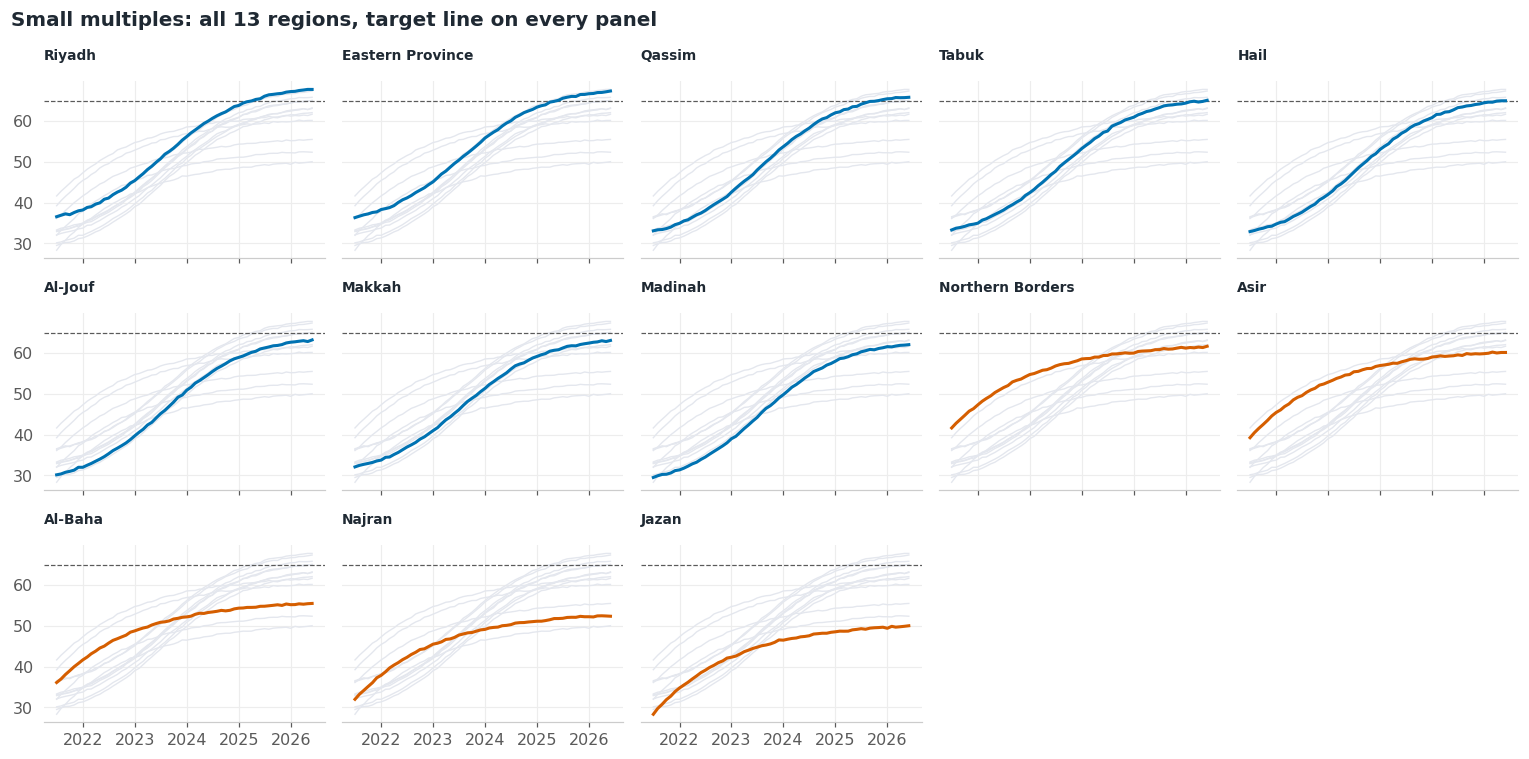

In [13]:
order = (mr[mr.month == mr.month.max()].sort_values("adoption", ascending=False).region.tolist())
fig, axes = plt.subplots(3, 5, figsize=(14, 7), sharex=True, sharey=True)
for ax, reg in zip(axes.ravel(), order):
    for other in order:
        o = mr[mr.region == other]
        ax.plot(o.month, o.adoption, color="#E4E7EE", lw=0.9, zorder=1)
    sub = mr[mr.region == reg]
    colour = tv.ACCENT if reg in tv.STALLED else tv.CATEGORICAL[0]
    ax.plot(sub.month, sub.adoption, color=colour, lw=2.0, zorder=3)
    ax.axhline(tv.TARGET_ADOPTION, color=tv.GREY_DARK, ls="--", lw=0.8, zorder=2)
    ax.set_title(reg, fontsize=9, loc="left", color=tv.INK)
    ax.spines[["top", "right"]].set_visible(False)
for ax in axes.ravel()[len(order):]:
    ax.axis("off")
fig.suptitle("Small multiples: all 13 regions, target line on every panel",
             x=0.01, ha="left", fontsize=13, fontweight="bold", color=tv.INK)
fig.tight_layout(); tv.save_fig(fig, "lab4b_small_multiples")
print("Small multiples written to notebooks/out/lab4b_small_multiples.png")

### Task 3 · (5 min) The comparison question, timed

Your partner asks, without warning: **among the six largest regions, which pair changed places between month 20 and month 44?**
Answer it from the animation, then from the grid. Time both. The question deliberately uses two
NON-ADJACENT time points — that is where animation fails.

In [14]:
BIG6 = (mr[mr.month == mr.month.max()]
        .nlargest(6, "transactions").region.tolist())
w = mr[(mr.region.isin(BIG6)) &
       (mr.month >= mr.month.min() + pd.DateOffset(months=20)) &
       (mr.month <= mr.month.min() + pd.DateOffset(months=44))]
piv = w.pivot_table(index="month", columns="region", values="adoption")

crossings = []
for i, a in enumerate(piv.columns):
    for b in piv.columns[i + 1:]:
        d = piv[a] - piv[b]
        if (d.iloc[0] > 0) != (d.iloc[-1] > 0):
            crossings.append((a, b, abs(d.iloc[0]), abs(d.iloc[-1])))
crossings.sort(key=lambda t: -(t[2] + t[3]))

print(f"Six largest regions: {BIG6}")
print(f"{len(crossings)} pair(s) changed places between month 20 and month 44:")
for a, b, g0, g1 in crossings:
    print(f"   {a} and {b}  (gap {g0:.2f} pp -> {g1:.2f} pp, sign reversed)")
print("\nThe grid answers this by eye. The animation cannot: the two time points are")
print("60 seconds of playback apart, so the comparison lives entirely in working memory.")

Six largest regions: ['Riyadh', 'Makkah', 'Eastern Province', 'Asir', 'Madinah', 'Jazan']
5 pair(s) changed places between month 20 and month 44:
   Jazan and Madinah  (gap 2.57 pp -> 10.09 pp, sign reversed)
   Asir and Riyadh  (gap 6.67 pp -> 5.42 pp, sign reversed)
   Asir and Makkah  (gap 11.13 pp -> 0.56 pp, sign reversed)
   Jazan and Makkah  (gap 0.42 pp -> 11.19 pp, sign reversed)
   Asir and Eastern Province  (gap 6.76 pp -> 4.66 pp, sign reversed)

The grid answers this by eye. The animation cannot: the two time points are
60 seconds of playback apart, so the comparison lives entirely in working memory.


### Task 4 · (4 min) Record the decision

Write the two times on the benchmark sheet, then state which view you would ship, for which audience, and why.

In [15]:
bench = pd.DataFrame({
    "view":            ["Animated", "Small multiples"],
    "task":            ["non-adjacent comparison"] * 2,
    "robertson_2008_s": [83.1, 45.7],
    "your_time_s":     [np.nan, np.nan],      # <- fill in from the room
    "ship_it_for":     ["a narrated walkthrough where you control attention",
                        "a dashboard someone else explores without you"],
})
print(bench.to_string(index=False))
bench.to_csv(tv.OUT / "lab4b_animation_benchmark.csv", index=False)
print("\nDecision rule: if you will be standing next to it talking, animate.")
print("If they will open it alone on a Tuesday, small multiples. Build only the one you need.")

           view                    task  robertson_2008_s  your_time_s                                        ship_it_for
       Animated non-adjacent comparison              83.1          NaN a narrated walkthrough where you control attention
Small multiples non-adjacent comparison              45.7          NaN      a dashboard someone else explores without you

Decision rule: if you will be standing next to it talking, animate.
If they will open it alone on a Tuesday, small multiples. Build only the one you need.
